

# 1. Enriched LSTM Model Overview
-----------------

This notebook implements a Enriched Long Short-Term Memory (LSTM) based recommendation model using a FAISS negative sampling after feature representation is refined

**Key Aspects:**
*   **Splitting Strategy:** Utilizes a k-2, k-1, k split for training, validation, and testing.
*   **Objective:** Predict the next item in a user's recommendation sequence.
*   **Embeddings:** Incorporates `item_semantic_embedding_static` derived from book title, description, and top shelf tags
    - User-item matching: `user_author_interaction_share_before_t`, `num_pages_preference_gap`, `user_profile_embedding_similarity`
    - User history: `user_hist_interaction_count_before_t`, `user_hist_author_diversity_before_t`, `days_since_user_last_interaction`
    - Structured metadata: `num_pages`, `publication_year`, `format_collapsed`, `is_ebook`, `language_code_collapsed`, `main_author_id`
    - Item temporal popularity: `book_interactions_count_before_t`, `days_since_book_last_interaction`, `author_interactions_count_before_t`
*   **Loss Function:** Uses Hybrid Loss for optimisation.
    - Cross-Entropy loss (**weight = 0.4**)
    - BPR loss (**weight = 0.6**)
*   **Negative Sampling:** Uses FAISS to retrieve nearest-neighbour negatives from `item_semantic_embedding_static`, with a popularity-based fallback in **training** only

# 2. Imports

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
import torch
import random
from torch.utils.data import Dataset
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/BT4222Project/final_updated_baseline_df.pkl'
full_df = pd.read_pickle(file_path)

# Maintain chronological ordering
full_df = full_df.sort_values(['user_id', 'event_time']).reset_index(drop=True)

Mounted at /content/drive


# 3. Metrics used in the model
- Hit Rate: Was the subsequent(target) book recommended in the top K
- MAP/NDCG: Was the subsequent(target) book ranked high in the top K

In [ ]:
def hit_rate(preds, targets, k=10):
    """
    preds: numpy array of shape (batch_size, num_items), predicted scores
    targets: numpy array of shape (batch_size,), true item indices
    """
    top_k = np.argsort(-preds, axis=1)[:, :k]
    hits = [t in top for t, top in zip(targets, top_k)]
    return np.mean(hits)

def map_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ap_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1  # 1-based
            ap_list.append(1.0 / rank)
        else:
            ap_list.append(0.0)
    return np.mean(ap_list)

def ndcg_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ndcg_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ndcg_list.append(1.0 / np.log2(rank + 1))
        else:
            ndcg_list.append(0.0)
    return np.mean(ndcg_list)

def calculate_batch_metrics(top_k_indices, targets):
    """
    top_k_indices: numpy array of shape (batch_size, k)
    targets: numpy array of shape (batch_size,)
    Returns the sum of HR, MAP, and NDCG for the batch.
    """
    hits, map_sum, ndcg_sum = 0, 0, 0

    for t, top in zip(targets, top_k_indices):
        if t in top:
            hits += 1
            rank = np.where(top == t)[0][0] + 1
            map_sum += 1.0 / rank
            ndcg_sum += 1.0 / np.log2(rank + 1)

    return hits, map_sum, ndcg_sum

# 4. Index Representation for Embeddings

This section details the creation of numerical index representations for users and books, used for embedding layers in the model.

In [ ]:
# Shifted +1 to reserve 0 for padding
user2idx = {u: i + 1 for i, u in enumerate(full_df['user_id'].unique())}
book2idx = {b: i + 1 for i, b in enumerate(full_df['book_id'].unique())}

full_df['user_idx'] = full_df['user_id'].map(user2idx)
full_df['book_idx'] = full_df['book_id'].map(book2idx)

num_users = len(user2idx)
num_books = len(book2idx)

full_df = full_df.sort_values(['user_id', 'event_time']).reset_index(drop=True)

# Build full user sequences in chronological order
def build_user_sequences(df):
    user_seq = defaultdict(list)

    for user, group in df.groupby('user_idx'):
        user_seq[user] = group.index.tolist()
    return user_seq

full_seq = build_user_sequences(full_df)

## 5. Numerical Feature Scaling and Imputation of NaN

- Scaled and Normalised

In [ ]:

# ── Numeric NaN imputation ──
print("Attempting to fill num_pages and publication_year from other interactions of the same book_id...")
book_info_map = full_df.groupby('book_id').agg({
    'num_pages': lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan,
    'publication_year': lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan
}).reset_index()
full_df = full_df.set_index('book_id').combine_first(book_info_map.set_index('book_id')).reset_index()

numerical_cols = [
    "num_pages", "publication_year", "is_ebook",
    "book_interactions_count_before_t", "days_since_book_last_interaction",
    "author_interactions_count_before_t",
    "user_author_interaction_share_before_t", "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    "user_hist_interaction_count_before_t", "user_hist_author_diversity_before_t",
    "days_since_user_last_interaction",
]

print("NaN values before final imputation:")
print(full_df[numerical_cols].isnull().sum())

median_cols = ['num_pages', 'publication_year', 'book_interactions_count_before_t',
               'author_interactions_count_before_t', 'user_hist_interaction_count_before_t']
for col in numerical_cols:
    if full_df[col].isnull().any():
        if col in median_cols:
            full_df[col] = full_df[col].fillna(full_df[col].median())
        else:
            full_df[col] = full_df[col].fillna(full_df[col].mean())

print("\nNaN values after final imputation:")
print(full_df[numerical_cols].isnull().sum())

# Log-transform to resolve heavy-tailed feature
log_cols = [
    "num_pages",
    "book_interactions_count_before_t",
    "author_interactions_count_before_t",
    "user_hist_interaction_count_before_t",
    "days_since_book_last_interaction",
    "days_since_user_last_interaction",
]

for col in log_cols:
    if col in full_df.columns:
        full_df[col] = np.log1p(full_df[col].clip(lower=0))

# Standardize
scaler = StandardScaler()
full_df[numerical_cols] = scaler.fit_transform(full_df[numerical_cols].astype(np.float32))

# Clip outliers
full_df[numerical_cols] = full_df[numerical_cols].clip(-5, 5)

Attempting to fill num_pages and publication_year from other interactions of the same book_id...
NaN values before final imputation:
num_pages                                  889505
publication_year                           974003
is_ebook                                        0
book_interactions_count_before_t                0
days_since_book_last_interaction           123087
author_interactions_count_before_t              0
user_author_interaction_share_before_t     454189
num_pages_preference_gap                  1338063
user_profile_embedding_similarity          454189
user_hist_interaction_count_before_t       454189
user_hist_author_diversity_before_t             0
days_since_user_last_interaction           454189
dtype: int64

NaN values after final imputation:
num_pages                                 0
publication_year                          0
is_ebook                                  0
book_interactions_count_before_t          0
days_since_book_last_interaction          

## 6. Categorical Feature Encoding

In [ ]:
def make_vocab(series):
    vocab = {"__PAD__": 0}
    values = pd.Series(series).fillna("__UNK__").astype(str).unique()
    for v in values:
        if v not in vocab:
            vocab[v] = len(vocab)
    return vocab

format_vocab = make_vocab(full_df["format_collapsed"])
lang_vocab   = make_vocab(full_df["language_code_collapsed"])
author_vocab = make_vocab(full_df["main_author_id"])

full_df["format_idx"] = (
    full_df["format_collapsed"].fillna("__UNK__").astype(str).map(format_vocab).fillna(0).astype(np.int64)
)
full_df["lang_idx"] = (
    full_df["language_code_collapsed"].fillna("__UNK__").astype(str).map(lang_vocab).fillna(0).astype(np.int64)
)
full_df["author_idx"] = (
    full_df["main_author_id"].fillna("__UNK__").astype(str).map(author_vocab).fillna(0).astype(np.int64)
)

# 7. Data Splitting Strategy

The dataset is split into training, validation, and test sets using a time-aware approach. For each user's sequence of interactions, the following splits are applied:

*   **Training Set**: Includes all interactions up to the third-to-last item (k-2).
*   **Validation Set**: Used for predicting the second-to-last item (k-1).
*   **Test Set**: Used for predicting the last item (k).

Apply the designated split method

In [ ]:
# Split sequences into k-2, k-1, k
train_seq, val_seq, test_seq = {}, {}, {}

# Grouped the user
for user, seq in full_seq.items():
    if len(seq) < 3:
        continue

    train_seq[user] = seq[:-2]
    val_seq[user] = seq[:-1]
    test_seq[user] = seq

# 8. Negative Sampling: FAISS
A FAISS index is built over L2-normalised `item_semantic_embedding_static` to enable efficient retrieval of semantically similar items for downstream negative sampling.

In [ ]:
!pip install faiss-cpu
import faiss

# 1. Prepare all item embeddings in index order (1 to num_books)
embedding_dim = full_df['item_semantic_embedding_static'].iloc[0].shape[0]
all_item_embs = np.zeros((num_books + 1, embedding_dim), dtype='float32')

# Map book_idx to its static embedding from the dataframe
# We drop duplicates to get one embedding per book_idx
item_meta = full_df[['book_idx', 'item_semantic_embedding_static']].drop_duplicates('book_idx')
for _, row in item_meta.iterrows():
    all_item_embs[row['book_idx']] = row['item_semantic_embedding_static'].astype('float32')

# 2. Initialize FAISS index
# Using IndexFlatIP for Inner Product (Cosine Similarity if vectors are normalized)
faiss_index = faiss.IndexFlatIP(embedding_dim)

# Optional: Normalize for true Cosine Similarity
faiss.normalize_L2(all_item_embs)
faiss_index.add(all_item_embs)

print(f"FAISS index built with {faiss_index.ntotal} items.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 110.6 MB/s eta 0:00:00
FAISS index built with 123088 items.


# 9. Negative Sampling Fallback: Identifying Popular Items

In [ ]:
top_1000_books = full_df['book_idx'].value_counts().head(1000).index.tolist()
print(f"Identified {len(top_1000_books)} popular items for fallback sampling.")

Identified 1000 popular items for fallback sampling.


# 10. Sequential Dataset and DataLoader Configuration

This section outlines the creation of the `SequentialBookRecDataset` and its configuration. Key parameters include:

*   **Context Window**: Sequences are limited to a length of 10, capturing the most recent interactions for prediction.
*   **Padding Strategy**: Shorter sequences are left-padded with a dedicated padding index (0) to ensure uniform input dimensions for the model.
*   **FAISS-Based Hard Negatives**: Negative samples are selected using a precomputed FAISS index over item semantic embeddings to retrieve nearest-neighbour candidates in the embedding space
    - Popularity-based fallback is used when no valid FAISS negatives books are available
    - Random sampling is used as a final fallback to ensure robustness across all users

In [ ]:
class SequentialBookRecDataset(Dataset):
    def __init__(self, user_seq, full_user_seq, df, num_books, top_popular_books, faiss_index, all_item_embs, seq_len=10, split='train'):
        self.seq_len = seq_len
        self.split = split
        self.df = df
        self.user_seq = user_seq
        self.full_user_history_set = {u: set(seq) for u, seq in full_user_seq.items()}
        self.num_books = num_books
        self.top_popular_books = top_popular_books
        self.faiss_index = faiss_index
        self.all_item_embs = all_item_embs

        self.books = df['book_idx'].values
        self.static_emb = np.vstack(df['item_semantic_embedding_static'].values)

        # Enriched numerical features
        self.numerical_cols = [
            # Static item metadata
            "num_pages", "publication_year", "is_ebook",
            # Item temporal popularity
            "book_interactions_count_before_t", "days_since_book_last_interaction",
            "author_interactions_count_before_t",
            # User-item matching
            "user_author_interaction_share_before_t", "num_pages_preference_gap",
            "user_profile_embedding_similarity",
            # User history
            "user_hist_interaction_count_before_t", "user_hist_author_diversity_before_t",
            "days_since_user_last_interaction",
        ]
        self.num_feats = df[self.numerical_cols].values.astype(np.float32)
        self.format_idx = df['format_idx'].values
        self.lang_idx   = df['lang_idx'].values
        self.author_idx = df['author_idx'].values

        self.samples = []
        for user_id, indices in self.user_seq.items():
            n = len(indices)
            if n < 3: continue
            if split == 'train':
                for pos in range(1, n - 2): self.samples.append((user_id, pos))
            elif split == 'val': self.samples.append((user_id, n - 2))
            elif split == 'test': self.samples.append((user_id, n - 1))

        self.hard_neg_pool = {}
        if self.split == 'train': self.refresh_hard_negatives()

    def refresh_hard_negatives(self, current_item_embs=None):
        """Uses FAISS to find similar items for hard negative sampling"""
        print(f"Refreshing hard negative pool for {self.split} using FAISS...")
        if current_item_embs is not None:
            embs = current_item_embs.copy().astype('float32')
            faiss.normalize_L2(embs)
            new_index = faiss.IndexFlatIP(embs.shape[1])
            new_index.add(embs)
            self.faiss_index = new_index
            search_embs = embs
        else: search_embs = self.all_item_embs

        unique_targets = list(set([self.books[self.user_seq[u][p]] for u, p in self.samples]))
        target_embs = search_embs[unique_targets].astype('float32')

        # FAISS SEARCH: Find top 10 most similar items to serve as hard negatives
        _, indices = self.faiss_index.search(target_embs, 10)
        self.hard_neg_pool = {target: neighbors.tolist() for target, neighbors in zip(unique_targets, indices)}

    def __len__(self): return len(self.samples)

    def _get_hard_negative(self, user_id, target_idx):
        if target_idx in self.hard_neg_pool:
            for neg_item in self.hard_neg_pool[target_idx]:
                if neg_item != 0 and neg_item != target_idx and neg_item not in self.full_user_history_set[user_id]:
                    return int(neg_item)
        for _ in range(5):
            neg_item = random.choice(self.top_popular_books)
            if neg_item not in self.full_user_history_set[user_id]: return neg_item
        return random.randint(1, self.num_books)

    def __getitem__(self, idx):
        user_id, pos = self.samples[idx]
        indices = self.user_seq[user_id]
        start = max(0, pos - self.seq_len)
        seq_idx = indices[start:pos]

        actual_book_ids = self.books[seq_idx]
        actual_static_emb = self.static_emb[seq_idx]
        actual_nums = self.num_feats[seq_idx]
        actual_formats = self.format_idx[seq_idx]
        actual_langs = self.lang_idx[seq_idx]
        actual_authors = self.author_idx[seq_idx]

        pad_len = self.seq_len - len(seq_idx)
        if pad_len > 0:
            actual_book_ids = np.concatenate([np.zeros(pad_len, dtype=int), actual_book_ids])
            actual_static_emb = np.concatenate([np.zeros((pad_len, actual_static_emb.shape[1]), dtype=np.float32), actual_static_emb])
            actual_nums = np.concatenate([np.zeros((pad_len, len(self.numerical_cols)), dtype=np.float32), actual_nums])
            actual_formats = np.concatenate([np.zeros(pad_len, dtype=int), actual_formats])
            actual_langs = np.concatenate([np.zeros(pad_len, dtype=int), actual_langs])
            actual_authors = np.concatenate([np.zeros(pad_len, dtype=int), actual_authors])

        target_book_id = self.books[indices[pos]]
        return {
            'seq_book_ids':  torch.LongTensor(actual_book_ids),
            'seq_static_emb': torch.FloatTensor(actual_static_emb),
            'seq_num_feats': torch.FloatTensor(actual_nums),
            'seq_format_ids': torch.LongTensor(actual_formats),
            'seq_lang_ids':  torch.LongTensor(actual_langs),
            'seq_author_ids': torch.LongTensor(actual_authors),
            'user_id':       torch.LongTensor([user_id]),
            'target':        torch.LongTensor([target_book_id]),
            'neg_target':    torch.LongTensor([self._get_hard_negative(user_id, target_book_id)])
        }


# 11. DataLoader Creation
This section initializes the `DataLoader` objects for the training, validation, and test datasets, facilitating efficient batch processing during model training and evaluation.

In [ ]:
train_dataset = SequentialBookRecDataset(train_seq, full_seq, full_df, num_books, top_1000_books, faiss_index, all_item_embs, split='train')
val_dataset   = SequentialBookRecDataset(val_seq, full_seq, full_df, num_books, top_1000_books, faiss_index, all_item_embs, split='val')
test_dataset  = SequentialBookRecDataset(test_seq, full_seq, full_df, num_books, top_1000_books, faiss_index, all_item_embs, split='test')

# Increased batch size for faster processing
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=2048, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False, num_workers=2)

Refreshing hard negative pool for train using FAISS...


# 12. Fusion Block

This section introduces the `FusionBlock`, a fundamental building block used throughout the model's architecture.

**Purpose:**
*   **Feature Transformation**: Linearly transforms input features to a desired output dimension.
*   **Normalization**: Applies Layer Normalization to stabilize activations and improve training.
*   **Non-linearity**: Uses a GELU activation function to introduce non-linearity.
*   **Regularization**: Incorporates Dropout to prevent overfitting.
*   **Residual Connections**: Employs a residual connection to help mitigate the vanishing gradient problem and improve information flow, especially in deeper networks.

In [ ]:
class FusionBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout))

    def forward(self, x):
        return self.net(x)

# 13. Sequential Model Definition

This section defines the multi-modal sequential architecture of the LSTM-based `SequentialBookRecModel`.

**Key Specifications:**

*   **Feature Groups:**
    *   Book ID embeddings
    *   Static semantic embeddings (`item_semantic_embedding_static`)
    *   Numerical features
    *   Categorical embeddings (format, language, author)

    These features are projected into `FusionBlocks` and concatenated into a unified 128 dimensional item representation. This representation is then passed through an LSTM layer to model temporal dependencies. The final sequence representation (last hidden state) is fed into a two-layer Feed-Forward Network (FFN) for next-item prediction.

*   **User Modelling & Gating:** A learned user embedding is dynamically fused with the sequence representation using a gating mechanism conditioned on the LSTM output. This mechanism performs interpolation between:
    *   Long-term user preference (user embedding)
    *   Short-term intent (sequence-derived representation)
    This allows for adaptive weighting based on behavioral context.

*   **Dropout:** A dropout rate of 0.3 is applied after the LSTM and within the FFN to mitigate overfitting.

*   **Negative Sampling:** FAISS-based nearest-neighbor sampling over `item_semantic_embedding_static` is used during training to retrieve hard negatives (top-K similar items to the target). These are filtered against the user’s full interaction history, with a popularity-based fallback.

In [ ]:
class SequentialBookRecModel(nn.Module):
    def __init__(self, num_users, num_books, num_formats, num_langs, num_authors,
                 book_emb_dim=64, user_emb_dim=16, lstm_hidden_dim=128, static_emb_dim=384, num_nums=12, dropout=0.3):
        super().__init__()
        self.book_emb   = nn.Embedding(num_books + 1, book_emb_dim, padding_idx=0)
        self.user_emb   = nn.Embedding(num_users + 1, user_emb_dim, padding_idx=0)

        # 0 reserved for padding
        self.format_emb = nn.Embedding(num_formats + 1, 16, padding_idx=0)
        self.lang_emb   = nn.Embedding(num_langs   + 1, 16, padding_idx=0)
        self.author_emb = nn.Embedding(num_authors + 1, 32, padding_idx=0)

        self.book_proj   = FusionBlock(book_emb_dim, 32)
        self.static_proj = FusionBlock(static_emb_dim, 64)
        self.num_proj    = FusionBlock(num_nums, 32)
        self.cat_proj    = FusionBlock(16 + 16 + 32, 32)

        # FINAL ITEM REPRESENTATION
        self.item_proj = FusionBlock(32 + 64 + 32 + 32, 128)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        self.user_gate = nn.Linear(lstm_hidden_dim, user_emb_dim)
        self.seq_to_user = nn.Linear(lstm_hidden_dim, user_emb_dim)

        self.ffn = nn.Sequential(
            nn.Linear(lstm_hidden_dim + user_emb_dim, 256),
            nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128), nn.GELU(),
            nn.Linear(128, num_books + 1)
        )

    def forward(self, seq_book_ids, seq_static_emb, seq_num_feats,
            seq_format_ids, seq_lang_ids, seq_author_ids, user_id):

      b = self.book_emb(seq_book_ids)
      s = self.static_proj(seq_static_emb)
      n = self.num_proj(seq_num_feats)

      f = self.format_emb(seq_format_ids)
      l = self.lang_emb(seq_lang_ids)
      a = self.author_emb(seq_author_ids)

      c = self.cat_proj(torch.cat([f, l, a], dim=-1))

      x = torch.cat([self.book_proj(b), s, n, c], dim=-1)
      x = self.item_proj(x)

      lstm_out, _ = self.lstm(x)
      seq_repr = self.dropout(lstm_out[:, -1, :])

      user_vec = self.user_emb(user_id.squeeze(1))

      gate = torch.sigmoid(self.user_gate(seq_repr))
      seq_user = self.seq_to_user(seq_repr)
      fused_user = gate * user_vec + (1 - gate) * seq_user

      logits = self.ffn(torch.cat([seq_repr, fused_user], dim=-1))
      return logits

# 14. Hybrid(BPR-CE) Loss Function
This section introduces the hybrid loss function combining Bayesian Personalized Ranking (BPR) loss and Cross-Entropy (CE) loss.

The two objectives are linearly combined using weighting coefficients to balance pairwise ranking optimisation (BPR) with global classification-based learning (CE).

In [ ]:
class BPRLoss(nn.Module):
    def __init__(self):
        super(BPRLoss, self).__init__()

    def forward(self, pos_scores, neg_scores):
        """
        pos_scores: Model's predicted score for the actual next book
        neg_scores: Model's predicted score for a randomly sampled unread book
        """
        # BPR Loss: -mean(log(sigmoid(pos_scores - neg_scores)))
        loss = -torch.mean(F.logsigmoid(pos_scores - neg_scores))
        return loss
class HybridLoss(nn.Module):
    def __init__(self, bpr_weight=0.5):
        super(HybridLoss, self).__init__()
        self.bpr_criterion = BPRLoss()
        self.ce_criterion = nn.CrossEntropyLoss(ignore_index=0) # ignore padding index 0
        self.bpr_weight = bpr_weight

    def forward(self, pos_scores, neg_scores, all_item_logits, targets_for_ce):
        bpr_loss = self.bpr_criterion(pos_scores, neg_scores)
        ce_loss = self.ce_criterion(all_item_logits, targets_for_ce)
        return (self.bpr_weight * bpr_loss) + ((1 - self.bpr_weight) * ce_loss)

# 15. Model Initialization and Configuration

This section initialises the `SequentialBookRecModel` with specified parameters.

**Configuration:**
*   **Hybrid Loss Function:**: Combines `Bayesian Personalized Ranking` (BPR) loss and `Cross-Entropy` (CE) loss
     - 0.4 Cross Entropy
     - 0.6 Bayesian Personalised Ranking
*   **Optimiser:**: (`Adam`) with weight decay for L2 Regularisaion

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

num_users = len(user2idx)
num_books = len(book2idx)

model = SequentialBookRecModel(
    num_users=num_users,
    num_books=num_books,
    num_formats=len(format_vocab),
    num_langs=len(lang_vocab),
    num_authors=len(author_vocab),
    num_nums=len(numerical_cols),
    book_emb_dim=64,
    user_emb_dim=16,
    lstm_hidden_dim=128,
    static_emb_dim=embedding_dim,
    dropout=0.3,
).to(device)

criterion = HybridLoss(bpr_weight=0.6)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

# 16. Model Training Function

This section defines the `train_model` function, which orchestrates the training and validation loops, calculates performance metrics, and plots the training progress and rank distributions.

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, train_dataset, all_item_embs, epochs=10, device='cuda'):
    train_losses, val_losses = [], []
    hr_list, map_list, ndcg_list = [], [], []
    all_epoch_ranks = []

    for epoch in range(epochs):
        # ==========================================
        # 1. TRAINING PHASE
        # ==========================================
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            optimizer.zero_grad()
            logits = model(
                batch['seq_book_ids'].to(device),
                batch['seq_static_emb'].to(device),
                batch['seq_num_feats'].to(device),
                batch['seq_format_ids'].to(device),
                batch['seq_lang_ids'].to(device),
                batch['seq_author_ids'].to(device),
                batch['user_id'].to(device)
            )
            targets = batch['target'].squeeze(1).to(device)
            neg_targets = batch['neg_target'].squeeze(1).to(device)

            batch_indices = torch.arange(logits.size(0)).to(device)
            pos_scores = logits[batch_indices, targets]
            neg_scores = logits[batch_indices, neg_targets]

            # Pass all necessary arguments to the HybridLoss criterion
            loss = criterion(pos_scores, neg_scores, logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Refresh FAISS hard negatives using jointly-trained projected embeddings
        # so negative sampling progressively reflects preference relevance
        model.eval()
        with torch.no_grad():
            all_item_embs_tensor = torch.FloatTensor(all_item_embs).to(device)
            book_indices = torch.arange(all_item_embs_tensor.shape[0], device=device)
            book_emb_all = model.book_emb(book_indices)
            projected_embs = torch.cat([all_item_embs_tensor, book_emb_all], dim=-1)
            projected_embs = projected_embs.cpu().numpy().astype('float32')
        train_dataset.refresh_hard_negatives(projected_embs)

        # ==========================================
        # 2. VALIDATION PHASE
        # ==========================================
        model.eval()
        val_loss, total_hits, total_map, total_ndcg, num_val_samples = 0, 0, 0, 0, 0
        current_epoch_ranks = []

        with torch.no_grad():
            for batch in val_loader:
                logits = model(
                    batch['seq_book_ids'].to(device),
                    batch['seq_static_emb'].to(device),
                    batch['seq_num_feats'].to(device),
                    batch['seq_format_ids'].to(device),
                    batch['seq_lang_ids'].to(device),
                    batch['seq_author_ids'].to(device),
                    batch['user_id'].to(device)
                )
                targets = batch['target'].squeeze(1).to(device)
                neg_targets = batch['neg_target'].squeeze(1).to(device)

                # Calculate Hybrid Validation Loss
                batch_indices = torch.arange(logits.size(0)).to(device)
                pos_scores = logits[batch_indices, targets]
                neg_scores = logits[batch_indices, neg_targets]
                batch_loss = criterion(pos_scores, neg_scores, logits, targets)
                val_loss += batch_loss.item()

                # Get top 20 to calculate hits and near-misses
                _, top_indices = torch.topk(logits, k=20, dim=1)
                targets_np = targets.cpu().numpy()
                top_indices_np = top_indices.cpu().numpy()

                batch_hits, batch_map, batch_ndcg = calculate_batch_metrics(top_indices_np[:, :10], targets_np)
                total_hits += batch_hits
                total_map += batch_map
                total_ndcg += batch_ndcg
                num_val_samples += len(targets_np)

                for i in range(len(targets_np)):
                    match = np.where(top_indices_np[i] == targets_np[i])[0]
                    if len(match) > 0:
                        current_epoch_ranks.append(match[0] + 1)
                    else:
                        current_epoch_ranks.append(21)

        all_epoch_ranks.append(current_epoch_ranks)

        # Track Validation Loss
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        hr = total_hits / num_val_samples
        mapk = total_map / num_val_samples
        ndcg = total_ndcg / num_val_samples

        hr_list.append(hr); map_list.append(mapk); ndcg_list.append(ndcg)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | HR@10: {hr:.4f}")

    plot_final_results(train_losses, val_losses, hr_list, map_list, ndcg_list, all_epoch_ranks)

    return model, train_losses, val_losses, hr_list, map_list, ndcg_list

def plot_final_results(train_losses, val_losses, hr_list, map_list, ndcg_list, all_epoch_ranks):
    num_epochs = len(train_losses)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    epochs_range = range(1, num_epochs + 1)

    # 1. Plot Training and Validation Loss
    ax1.plot(epochs_range, train_losses, label='Train Loss', marker='o')
    ax1.plot(epochs_range, val_losses, label='Val Loss', marker='s')
    ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True)

    # 2. Plot HR, MAP, and NDCG
    ax2.plot(epochs_range, hr_list, label='HR@10', marker='o')
    ax2.plot(epochs_range, map_list, label='MAP@10', marker='s')
    ax2.plot(epochs_range, ndcg_list, label='NDCG@10', marker='^')
    ax2.set_title('Performance Metrics'); ax2.legend(); ax2.grid(True)
    plt.show()

    # 3. Plot Rank Distributions for each epoch in a grid
    cols = 2
    rows = (num_epochs + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = axes.flatten()

    for i in range(num_epochs):
        ranks = all_epoch_ranks[i]
        bins = np.arange(1, 23)
        counts, _ = np.histogram(ranks, bins=bins)
        props = counts / len(ranks)

        axes[i].bar(range(1, 11), props[:10], color='green')
        axes[i].bar(range(11, 21), props[10:20], color='red')
        axes[i].bar(21, props[20], color='gray')
        axes[i].set_title(f"Epoch {i+1} Rank Distribution")
        axes[i].set_xticks(range(1, 22))
        axes[i].set_xticklabels([str(x) for x in range(1, 21)] + ["20+"])

        for j, p in enumerate(props[:10]):
            if p > 0.05: axes[i].text(j+1, p, f"{p:.2f}", ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


# 17. Initiate Model Training
This cell executes the `train_model` function to commence the training process for the `SequentialBookRecModel` for 10 epochs

Epoch 1 [Train]: 100%|██████████| 3472/3472 [08:20<00:00,  6.94it/s]


Refreshing hard negative pool for train using FAISS...
Epoch 1/10 - Train Loss: 0.8395 | Val Loss: 0.4377 | HR@10: 0.9157


Epoch 2 [Train]: 100%|██████████| 3472/3472 [08:27<00:00,  6.85it/s]


Refreshing hard negative pool for train using FAISS...
Epoch 2/10 - Train Loss: 0.1933 | Val Loss: 0.3150 | HR@10: 0.9429


Epoch 3 [Train]: 100%|██████████| 3472/3472 [08:11<00:00,  7.06it/s]


...

Refreshing hard negative pool for train using FAISS...
Epoch 8/10 - Train Loss: 0.1026 | Val Loss: 0.2697 | HR@10: 0.9548


Epoch 9 [Train]: 100%|██████████| 3472/3472 [08:34<00:00,  6.74it/s]


Refreshing hard negative pool for train using FAISS...
Epoch 9/10 - Train Loss: 0.1014 | Val Loss: 0.2691 | HR@10: 0.9552


Epoch 10 [Train]: 100%|██████████| 3472/3472 [08:13<00:00,  7.04it/s]


Refreshing hard negative pool for train using FAISS...
Epoch 10/10 - Train Loss: 0.1003 | Val Loss: 0.2700 | HR@10: 0.9550


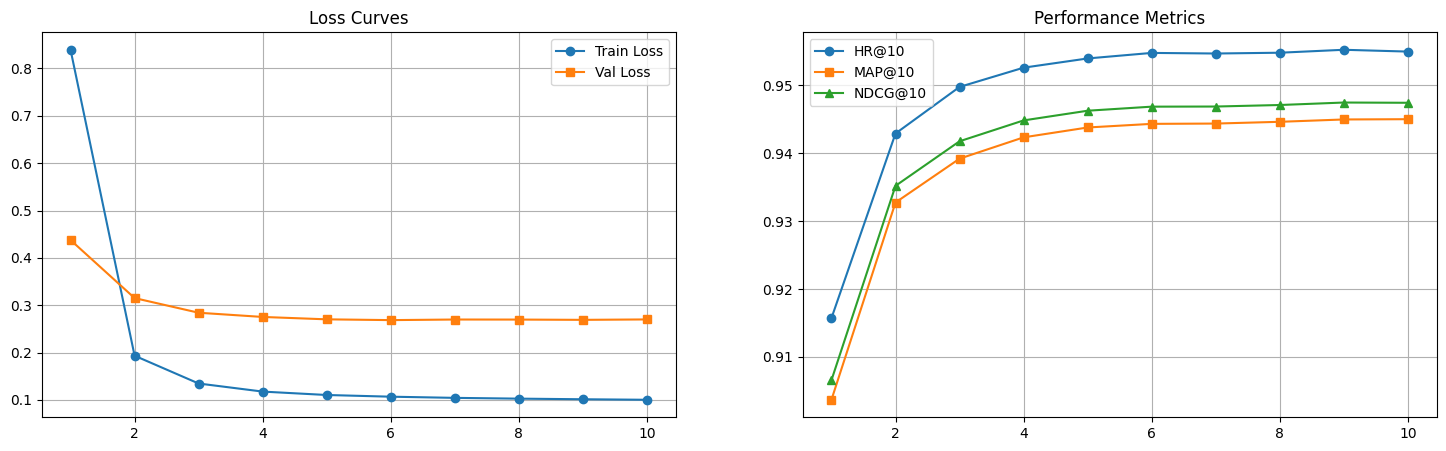

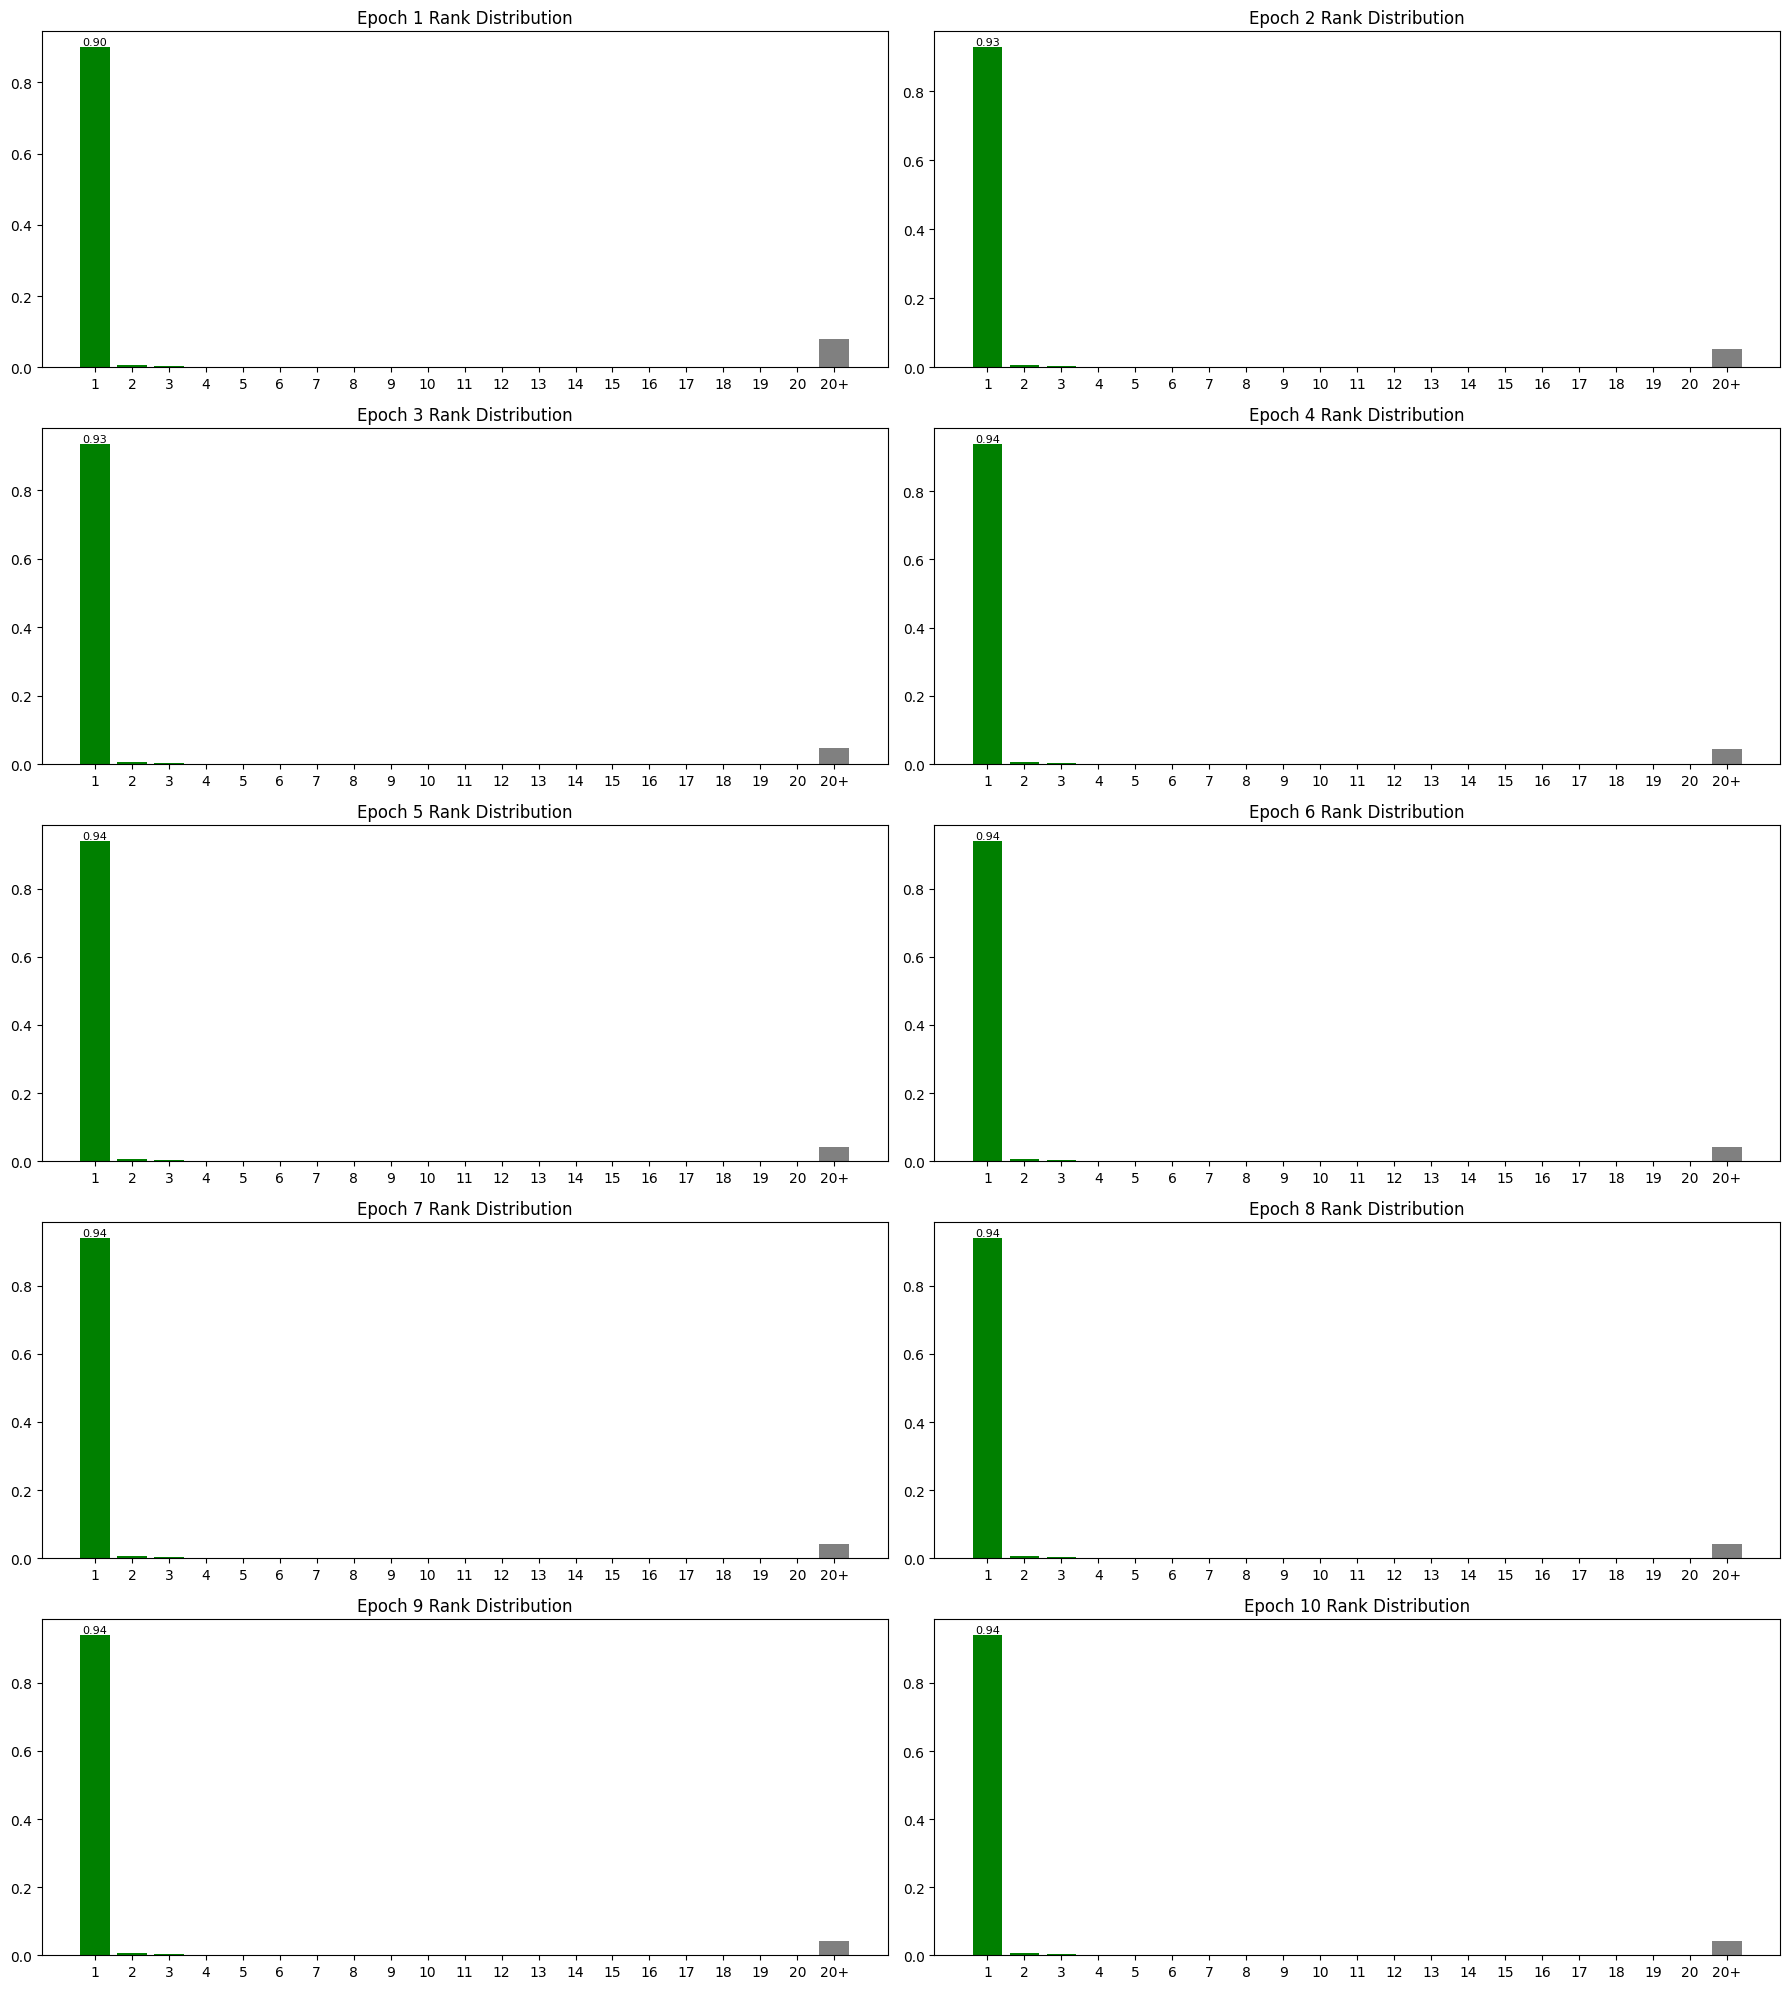

In [ ]:
trained_model = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    train_dataset=train_dataset,
    all_item_embs=all_item_embs,
    epochs=10,
    device=device
)

# 18. Model Evaluation on Test Set

This section defines and executes the `evaluate_test` function to assess the final performance of the trained hybrid model on the unseen test dataset using metrics such as Hit Rate, MAP, and NDCG.

In [ ]:
def evaluate_test(model, test_loader, device='cuda', k=10):
    model.eval()
    total_hits, total_map, total_ndcg = 0, 0, 0
    num_samples = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating Test Set"):
            logits = model(
                batch['seq_book_ids'].to(device),
                batch['seq_static_emb'].to(device),
                batch['seq_num_feats'].to(device),
                batch['seq_format_ids'].to(device),
                batch['seq_lang_ids'].to(device),
                batch['seq_author_ids'].to(device),
                batch['user_id'].to(device)
            )
            targets = batch['target'].squeeze(1).cpu().numpy()

            # Get top k indices directly on device, then move to CPU
            _, top_indices = torch.topk(logits, k=k, dim=1)
            top_indices = top_indices.cpu().numpy()

            batch_hits, batch_map, batch_ndcg = calculate_batch_metrics(top_indices, targets)

            total_hits += batch_hits
            total_map += batch_map
            total_ndcg += batch_ndcg
            num_samples += len(targets)

    metrics = {
        f'HR@{k}': total_hits / num_samples,
        f'MAP@{k}': total_map / num_samples,
        f'NDCG@{k}': total_ndcg / num_samples
    }

    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    return metrics

# Full test set evaluation
print("=== Full Test Set ===")
test_results = evaluate_test(model, test_loader, device=device)


=== Full Test Set ===


Evaluating Test Set: 100%|██████████| 155/155 [00:22<00:00,  6.82it/s]

HR@10: 0.9448
MAP@10: 0.9328
NDCG@10: 0.9357


# 19. Model Evaluation on Global Test Set

This section defines and executes the `evaluate_test` function to assess the final performance of the trained hybrid model on the unseen test dataset using metrics such as Hit Rate, MAP, and NDCG on 5000 users for comparison with NCF models.

In [ ]:
# Load the 5k user evaluation sample
eval_5k_df = pd.read_csv('/content/drive/My Drive/BT4222Project/global_temporal_test_eval_sample_5k_users.csv')

# Get the user indices for the 5k sample (filter to users present in our index)
eval_5k_user_ids = set(eval_5k_df['user_id'].unique())
eval_5k_user_idxs = set(u_idx for u_id, u_idx in user2idx.items() if u_id in eval_5k_user_ids)

# Build test sequences restricted to the 5k users
test_seq_5k = {u: seq for u, seq in test_seq.items() if u in eval_5k_user_idxs}

test_dataset_5k = SequentialBookRecDataset(
    test_seq_5k, full_seq, full_df, num_books, top_1000_books,
    faiss_index, all_item_embs, split='test'
)
test_loader_5k = DataLoader(test_dataset_5k, batch_size=2048, shuffle=False, num_workers=2)

print(f"Evaluating on {len(test_dataset_5k)} samples from 5k user subset")
print("=== 5k User Sample ===")
test_results_5k = evaluate_test(model, test_loader_5k, device=device)


Evaluating on 4842 samples from 5k user subset
=== 5k User Sample ===


Evaluating Test Set: 100%|██████████| 3/3 [00:01<00:00,  2.97it/s]

HR@10: 0.9463
MAP@10: 0.9373
NDCG@10: 0.9395


# 20. Analysis of Enriched LSTM model
Numerical features are log-scaled, clipped, and standardised to stabilise training and reduce dominance from high-variance signals.

Each modality (book ID, semantic embeddings, categorical, numerical) is processed through a projection block:

Linear → LayerNorm → GELU → Dropout

### Key mechanisms utilised

- Scale alignment: ensures comparable feature magnitudes across modalities
- Noise reduction: mitigates instability from sparse/noisy signals
- Feature transformation: introduces non-linear representation before fusion-

### Conclusion and Next Steps

Results confirm that interaction signals are highly informative when properly integrated.

However, the LSTM is constrained by:
- Limited temporal receptive field (fixed sequence length)
- Sequential bottleneck from hidden-state compression

We therefore propose a transition to a Transformer-based sequential recommender which:

- Uses masked self-attention to model full-sequence dependencies
- Removes sequential bottlenecks via direct token-to-token interactions
- Preserves causality through causal masking

This enables more expressive modelling of across user behaviour dynamics.
